# **Vectorized SMA Stretegy Backtesting**

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [36]:
company=["HAL.NS","BSE.NS","BEL.NS","FORTIS.NS"]
start_date="2023-01-01"
end_date="2026-01-06"
data=yf.download(company,start_date,end_date)
df=pd.DataFrame(data["Close"])
short_terms=1
long_terms=24
df

/tmp/ipython-input-3042833181.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(company,start_date,end_date)
[*********************100%***********************]  4 of 4 completed


Ticker,BEL.NS,BSE.NS,FORTIS.NS,HAL.NS
Date,,,,
2023-01-02,96.772728,181.139633,280.184814,1230.816040
2023-01-03,96.869255,184.217789,281.824524,1230.113647
2023-01-04,95.324760,179.413239,281.476685,1202.449829
2023-01-05,96.483139,178.273178,285.302582,1216.862915
2023-01-06,95.517830,176.546799,283.066681,1211.388306
...,...,...,...,...
2025-12-30,393.299988,2581.000000,878.799988,4325.500000
2025-12-31,399.600006,2632.199951,884.000000,4388.700195
2026-01-01,397.700012,2628.000000,900.549988,4397.899902


1. Creating Log return for each company
2. Create separate df strategy column for all 3 companies by using this formula:
> $$ \text{Today's strategy = Previous day's signal * Today's Log return}$$

In [37]:
result={}
for i in df.columns:
  temp=pd.DataFrame()
  temp["SMA_S"]=df.loc[:,i].rolling(window=short_terms).mean()
  temp["SMA_L"]=df.loc[:,i].rolling(window=long_terms).mean()
  temp["Signal"]=np.where(temp["SMA_S"]>temp["SMA_L"],1,-1)
  temp["LR"] = np.log(df[f"{i}"]/df[f"{i}"].shift(1))
  temp["Strategy"]=temp["Signal"].shift(1)*temp["LR"]
  temp.dropna(inplace=True)
  result[i]=temp
result["BEL.NS"]

,SMA_S,SMA_L,Signal,LR,Strategy
Date,,,,,
2023-02-03,90.594727,95.194043,-1,0.008024,-0.008024
2023-02-06,91.222168,94.962770,-1,0.006902,-0.006902
2023-02-07,91.173904,94.725463,-1,-0.000529,0.000529
2023-02-08,92.766678,94.618876,-1,0.017319,-0.017319
2023-02-09,92.477089,94.451958,-1,-0.003127,0.003127
...,...,...,...,...,...
2025-12-30,393.299988,397.385418,-1,0.000127,-0.000127
2025-12-31,399.600006,396.825002,1,0.015891,-0.015891
2026-01-01,397.700012,396.239586,1,-0.004766,-0.004766


**TASK: Separate all companies data by using for loop**

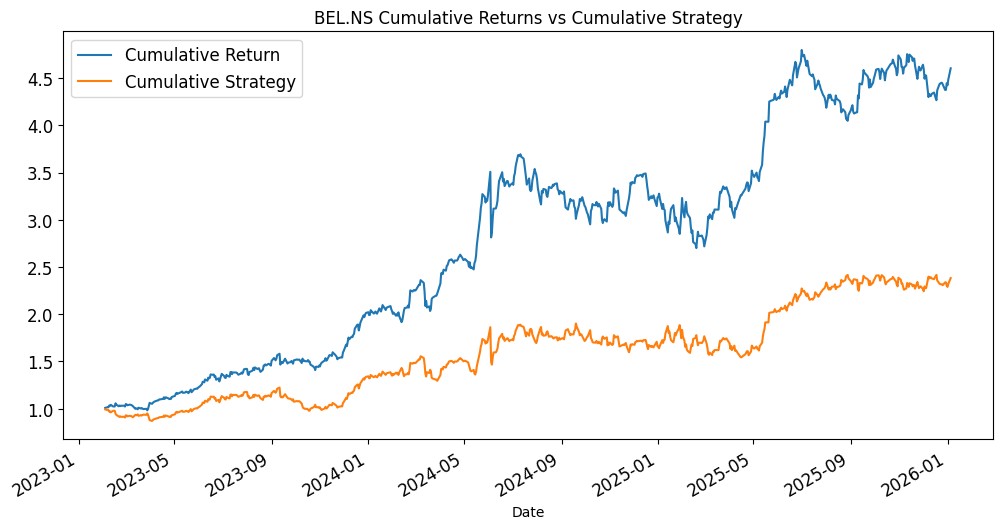

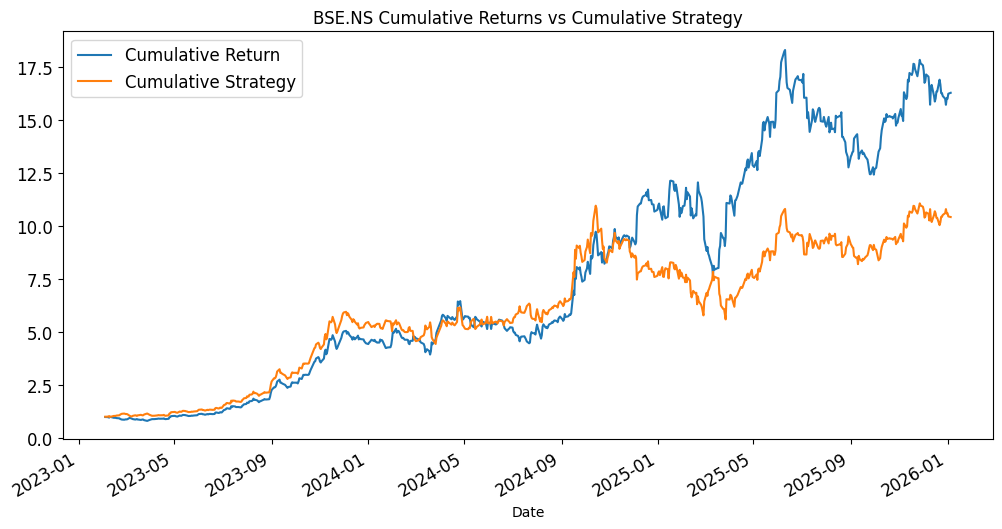

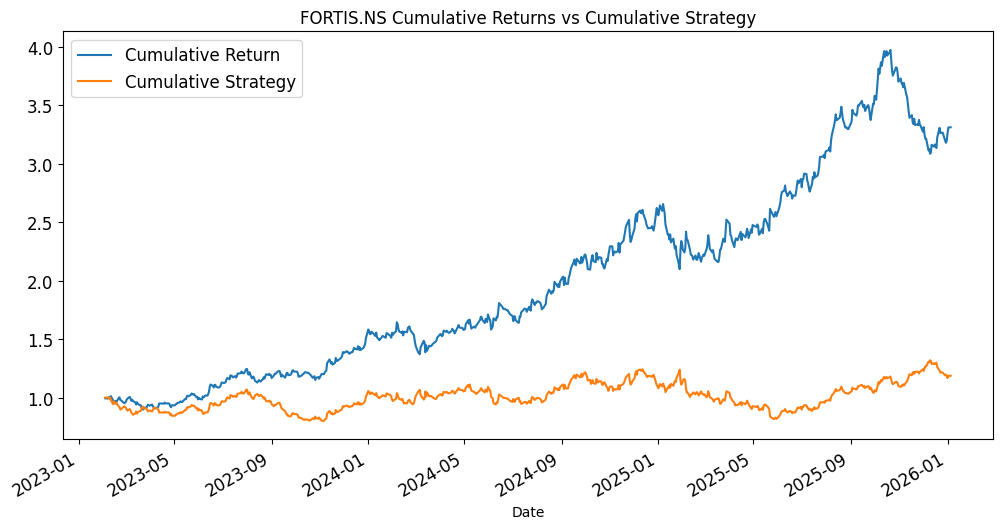

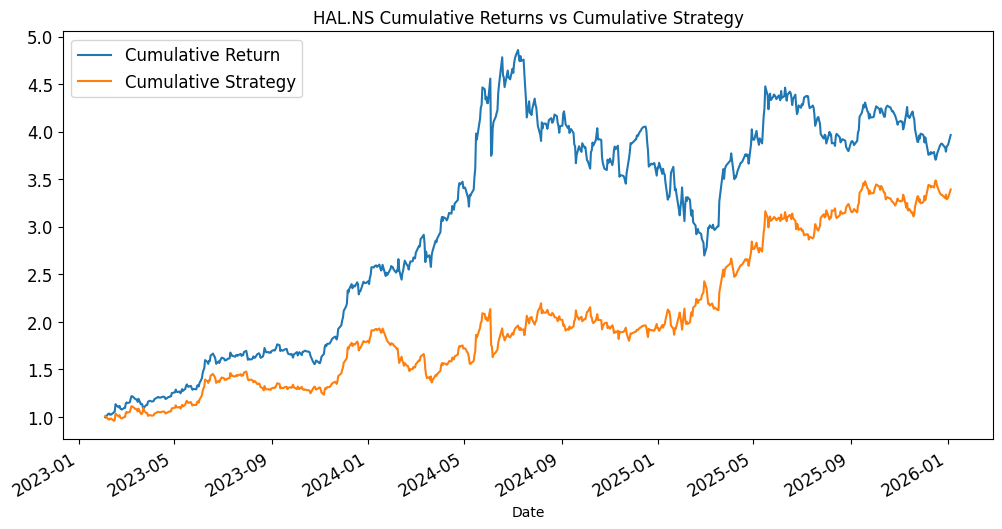

In [38]:
for i,df_i in result.items():
  df_i=result[i]
  df_i["Cumulative Return"]=df_i["LR"].cumsum().apply(np.exp)
  df_i["Cumulative Strategy"]=df_i["Strategy"].cumsum().apply(np.exp)
  df_i.dropna(inplace=True)
  df_i[["Cumulative Return","Cumulative Strategy"]].plot(figsize=(12,6),fontsize=12,title=f"{i} Cumulative Returns vs Cumulative Strategy")
  plt.legend(fontsize=12)
  plt.show()